In [5]:
import numpy as np
import pandas as pd

import cv2

import PIL
from PIL import Image
from PIL import ImageStat

import os

In [1]:
train_mask_dir = '..\\Data\\BUSI\\train\\mask\\'
test_mask_dir = '..\\Data\\BUSI\\test\\mask\\'

In [2]:
label = ['benign','malignant','normal']

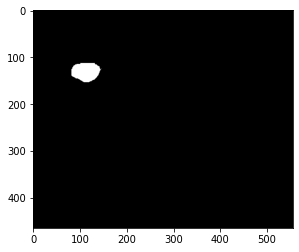

In [11]:
mask1  = cv2.imread('..\\Data\\BUSI\\train\\mask\\benign\\benign (4)_mask.png')
plt.imshow(mask1)
plt.show()

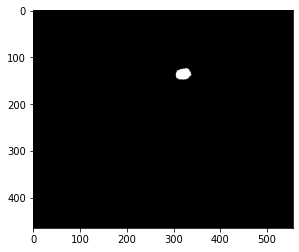

In [13]:
mask2  = cv2.imread('..\\Data\\BUSI\\train\\mask\\benign\\benign (4)_mask_1.png')
plt.imshow(mask2)
plt.show()

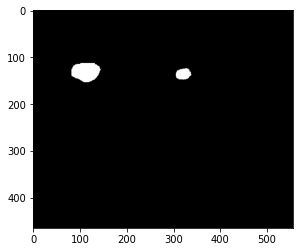

In [14]:
combined_mask = cv2.bitwise_or(mask1, mask2)
plt.imshow(combined_mask)
plt.show()

In [43]:
#@save
def combine(dir): 
    for i in range(0, 3):
        count = 0
        for root, dirs, files in os.walk(os.path.join(dir,label[i])):
            for file in files:
                duplicated_mask = []
                filename = file[0:-4]
                for another_file in files:
                    if another_file.startswith(filename):
                        duplicated_mask.append(another_file)
                if len(duplicated_mask)>=2:
                    count = count + len(duplicated_mask)
                    mask1 = cv2.imread(os.path.join(dir,label[i],duplicated_mask[0]))
                    mask2 = cv2.imread(os.path.join(dir,label[i],duplicated_mask[1]))
                    combined_mask = cv2.bitwise_or(mask1, mask2)
                    if len(duplicated_mask)>2:
                        for j in range(len(duplicated_mask)-2):
                            mask = cv2.imread(os.path.join(dir,label[i],duplicated_mask[j+2]))
                            combined_mask = cv2.bitwise_or(mask, combined_mask)
                    for duplicated_file in duplicated_mask:
                        os.remove(os.path.join(dir,label[i],duplicated_file))
                    cv2.imwrite(os.path.join(dir,label[i],file), combined_mask)
        print(count)                    
        print(label[i]+' finished')

In [44]:
combine(train_mask_dir)
combine(test_mask_dir)

29
benign finished
2
malignant finished
0
normal finished
4
benign finished
0
malignant finished
0
normal finished


修改合并后图像的通道数量

In [8]:
import os
from PIL import Image
import matplotlib.pyplot as plt


train_img_benign_adr = '..\\Data\\BUSI\\train\\image\\benign\\'
train_img_malignant_adr = '..\\Data\\BUSI\\train\\image\\malignant\\'
train_img_normal_adr = '..\\Data\\BUSI\\train\\image\\normal\\'
test_img_benign_adr = '..\\Data\\BUSI\\test\\image\\benign\\'
test_img_malignant_adr = '..\\Data\\BUSI\\test\\image\\malignant\\'
test_img_normal_adr = '..\\Data\\BUSI\\test\\image\\normal\\'

train_mask_benign_adr = '..\\Data\\BUSI\\train\\mask\\benign\\'
train_mask_malignant_adr = '..\\Data\\BUSI\\train\\mask\\malignant\\'
train_mask_normal_adr = '..\\Data\\BUSI\\train\\mask\\normal\\'
test_mask_benign_adr = '..\\Data\\BUSI\\test\\mask\\benign\\'
test_mask_malignant_adr = '..\\Data\\BUSI\\test\\mask\\malignant\\'
test_mask_normal_adr = '..\\Data\\BUSI\\test\\mask\\normal\\'

In [2]:
adr_set = [train_img_benign_adr,train_img_malignant_adr,train_img_normal_adr,test_img_benign_adr,test_img_malignant_adr,test_img_normal_adr,
           train_mask_benign_adr,train_mask_malignant_adr,train_mask_normal_adr,test_mask_benign_adr,test_mask_malignant_adr,test_mask_normal_adr]

In [3]:
def image_check():
    error_set = []
    for i in range(12):
        adr = adr_set[i]
        for file in os.listdir(adr):
            image = Image.open(os.path.join(adr, file))
            if 'normal' in file and 'mask' in file:
                nor_image = Image.new('1',(image.size[0],image.size[1]))
                image = nor_image
            if  not 'mask' in file and len(image.split())!=3:
                error_set.append(os.path.join(adr,file))
                print(os.path.join(adr,file), '---', len(image.split()))
            if 'mask' in file and len(image.split())!=1:
                error_set.append(os.path.join(adr, file))
                print(os.path.join(adr,file), '---', len(image.split()))
    return error_set

In [6]:
error_set = image_check()

..\Data\BUSI\train\mask\benign\benign (100)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (163)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (173)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (181)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (195)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (25)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (315)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (346)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (4)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (424)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (54)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (58)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (83)_mask.png --- 3
..\Data\BUSI\train\mask\benign\benign (92)_mask.png --- 3
..\Data\BUSI\train\mask\malignant\malignant (53)_mask.png --- 3
..\Data\BUSI\test\mask\benign\benign (93)_mask.png --- 3
..\Data\BUSI\test\mask\benign\benign (98)_mask.png --- 3


323 473
323 473


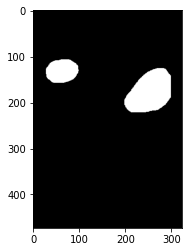

In [11]:
image = Image.open(os.path.join(error_set[0]))
print(image.size[0],image.size[1])
image = image.convert('1')
print(image.size[0],image.size[1])
plt.imshow(image)